In [1]:
import os
from pathlib import Path
import pandas as pd
import pysam
from icecream import ic
import numpy as np
from tqdm import tqdm

import sys
from pathlib import Path
# Add nuctool directory to path for imports
nuctool_path = Path.cwd().parent / 'nuctool'
if str(nuctool_path) not in sys.path:
    sys.path.insert(0, str(nuctool_path))
from Plotter import Plotter

from ChromatinFibers import (
    convert_to_footprints,
    fetch_chromosome_sequence,
    ChromatinFiber,
    compute_vanderlick,
)

from Plotter import Plotter, plot_sequence, plot_footprints
from pycorrelate import pcorrelate

plot = Plotter()
FILEOUT = rf"figures/SimulateYeastFibers.jpg"

# Create the directory if it doesn't exist
output_dir = os.path.dirname(FILEOUT)
if output_dir and not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created directory: {output_dir}")

In [2]:
filename = "occupancy_locus(chrII:273000-283000)"
occupancy = np.load(f"methylation_occupancy/{filename}.npy")
def extract_locus(locus_txt):
    locus_txt = locus_txt.replace(',', '')
    parts = locus_txt.split(':')
    chrom = parts[0]
    start, end = map(int, parts[1].split('-'))
    return (chrom, start, end)

locus = extract_locus(filename.lstrip("occupancy_locus(").rstrip(")"))
chrom, start, end = locus

In [3]:
chrom_number = chrom.lstrip("chr")

chromosome = fetch_chromosome_sequence(r".genomes/sacCer3/sacCer3.fa", chromosome=chrom_number)
length = end-start + 2000
#locus_start = np.random.randint(0, len(chromosome) - length)
locus_start = start - 1000
locus_end = locus_start + length
#locus_sequence = chromosome[-10001 : -1]
locus_sequence = chromosome[locus_start : locus_end]
fiber = ChromatinFiber(sequence=locus_sequence,start = locus_start)
fiber.fetch_orfs_by_range(start=locus_start, end=locus_end, chromosome=chrom_number)

Selected chromosome: .genomes/sacCer3, chrII  len=813184


In [4]:
from scipy.optimize import differential_evolution
from scipy.fft import rfft, irfft

def complex_spectral_fit_cc(y_data, physical_model_func, bounds, alpha=0.8):
    window = np.hanning(len(y_data))
    data_fft = rfft(y_data * window)
    data_var = np.var(y_data)

    def objective(params):
        model_sig = physical_model_func(*params)
        model_fft = rfft(model_sig * window)

        # Cross-correlation term — shape and phase
        cross_corr_spectrum = data_fft[5:160] * np.conj(model_fft[5:70])
        cross_corr = irfft(cross_corr_spectrum)
        zero_lag = cross_corr[0]
        norm_factor = np.sqrt(np.sum(np.abs(data_fft[5:70])**2) * 
                              np.sum(np.abs(model_fft[5:70])**2)) + 1e-10
        cc_term = -(zero_lag / norm_factor)  # bounded [-1, 1]

        # Amplitude term — penalise variance mismatch in signal space
        model_var = np.var(model_sig)
        amplitude_term = ((data_var - model_var) / (data_var + 1e-10)) ** 2  # bounded [0, 1]

        return (1 - alpha) * cc_term + alpha * amplitude_term

    res = differential_evolution(objective, bounds, strategy='best1bin', disp=True)
    return res.x

def complex_spectral_fit_lsq(y_data, physical_model_func, bounds):
    window = np.hanning(len(y_data))
    data_fft = rfft(y_data * window)

    def objective(params):
        model_sig = physical_model_func(*params)
        model_fft = rfft(model_sig * window)
        error_vector = data_fft[5:70] - model_fft[5:70]
        norm_factor = np.sqrt(np.sum(np.abs(data_fft[5:70])**2) * np.sum(np.abs(model_fft[5:70])**2))

        return np.sum(np.abs(error_vector)**2) / norm_factor

    res = differential_evolution(objective, bounds, strategy='best1bin', disp=True)
    return res.x

def model_func(period, amplitude, chemical_potential):
    fiber.calc_energy_landscape(
        octamer=True,
        period=period,
        amplitude=amplitude,
        chemical_potential=chemical_potential,
    )
    return fiber.occupancy[1000:-1000]

bounds = [
    (9.5, 10.5),    # period
    (0.001, 0.249),   # amplitude
    (0, 50),   # chemical_potential
]


In [5]:
period_lsq, amplitude_lsq, chemical_potential_lsq = complex_spectral_fit_lsq(
    occupancy, model_func, bounds
)
period_cc, amplitude_cc, chemical_potential_cc = complex_spectral_fit_cc(
    occupancy, model_func, bounds
)

differential_evolution step 1: f(x)= 1.6939318289742071
differential_evolution step 2: f(x)= 1.6939318289742071
differential_evolution step 3: f(x)= 1.6939318289742071
differential_evolution step 4: f(x)= 1.6939318289742071
differential_evolution step 5: f(x)= 1.6048003224525185
differential_evolution step 6: f(x)= 1.4959498649611909
differential_evolution step 7: f(x)= 1.4959498649611909
differential_evolution step 8: f(x)= 1.4959498649611909
differential_evolution step 9: f(x)= 1.4959498649611909
differential_evolution step 10: f(x)= 1.4959498649611909
differential_evolution step 11: f(x)= 1.4959498649611909
differential_evolution step 12: f(x)= 1.4959498649611909
differential_evolution step 13: f(x)= 1.4959498649611909
differential_evolution step 14: f(x)= 1.4959498649611909
differential_evolution step 15: f(x)= 1.4959498649611909
differential_evolution step 16: f(x)= 1.4959498649611909
differential_evolution step 17: f(x)= 1.4169281366477917
differential_evolution step 18: f(x)= 1.

RuntimeError: The map-like callable must be of the form f(func, iterable), returning a sequence of numbers the same length as 'iterable'

In [ ]:
# fiber.calc_energy_landscape(period=period_cc, amplitude=amplitude_cc, chemical_potential=chemical_potential_cc)
# cc_occupancy = fiber.occupancy[1000:-1000]
fiber.calc_energy_landscape(period=period_lsq, amplitude=amplitude_lsq, chemical_potential=chemical_potential_lsq)
lsq_occupancy = fiber.occupancy[1000:-1000]


<Axes: title={'center': 'Predicted vs. measured Complex spectral fit'}, xlabel='Measured occupancy', ylabel='Predicted occupancy'>

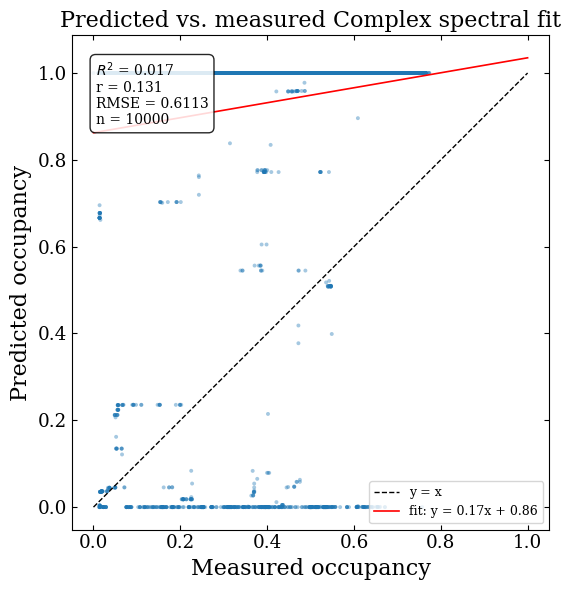

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

def plot_correlation(measured, predicted, ax=None, title=None):
    """
    Scatter plot of predicted vs measured values with R² and Pearson r.

    Parameters
    ----------
    measured : array-like
        Observed/experimental occupancy.
    predicted : array-like
        Model output (e.g. from model_func with fitted parameters).
    ax : matplotlib Axes, optional
        Existing axis to draw into. If None, a new figure is created.
    title : str, optional
    """
    measured = np.asarray(measured).ravel()
    predicted = np.asarray(predicted).ravel()

    if measured.shape != predicted.shape:
        raise ValueError(
            f"Shape mismatch: measured {measured.shape} vs predicted {predicted.shape}"
        )

    # Statistics
    r, p_value = pearsonr(measured, predicted)
    r_squared = r ** 2
    rmse = np.sqrt(np.mean((predicted - measured) ** 2))

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))

    # Scatter
    ax.scatter(measured, predicted, s=8, alpha=0.4, edgecolor='none')

    # y = x reference line
    lo = min(measured.min(), predicted.min())
    hi = max(measured.max(), predicted.max())
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1, label='y = x')

    # Linear fit line
    slope, intercept = np.polyfit(measured, predicted, 1)
    xs = np.array([lo, hi])
    ax.plot(xs, slope * xs + intercept, 'r-', lw=1.2,
            label=f'fit: y = {slope:.2f}x + {intercept:.2f}')

    ax.set_xlabel('Measured occupancy')
    ax.set_ylabel('Predicted occupancy')
    ax.set_title(title or 'Predicted vs. measured Complex spectral fit')
    ax.set_aspect('equal', adjustable='box')

    # Annotation box with stats
    stats_text = (
        f'$R^2$ = {r_squared:.3f}\n'
        f'r = {r:.3f}\n'
        f'RMSE = {rmse:.4f}\n'
        f'n = {len(measured)}'
    )
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
            va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85))

    ax.legend(loc='lower right', fontsize=9)
    plt.tight_layout()
    return ax

plot_correlation(occupancy, lsq_occupancy)